In [4]:
import pandas as pd

df_steel = pd.read_csv("data/Steel_industry_data.csv")
df_steel.head()
df_small = df_steel.head(1000)
df_steel.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


date                                    0
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_of_week                             0
Load_Type                               0
dtype: int64

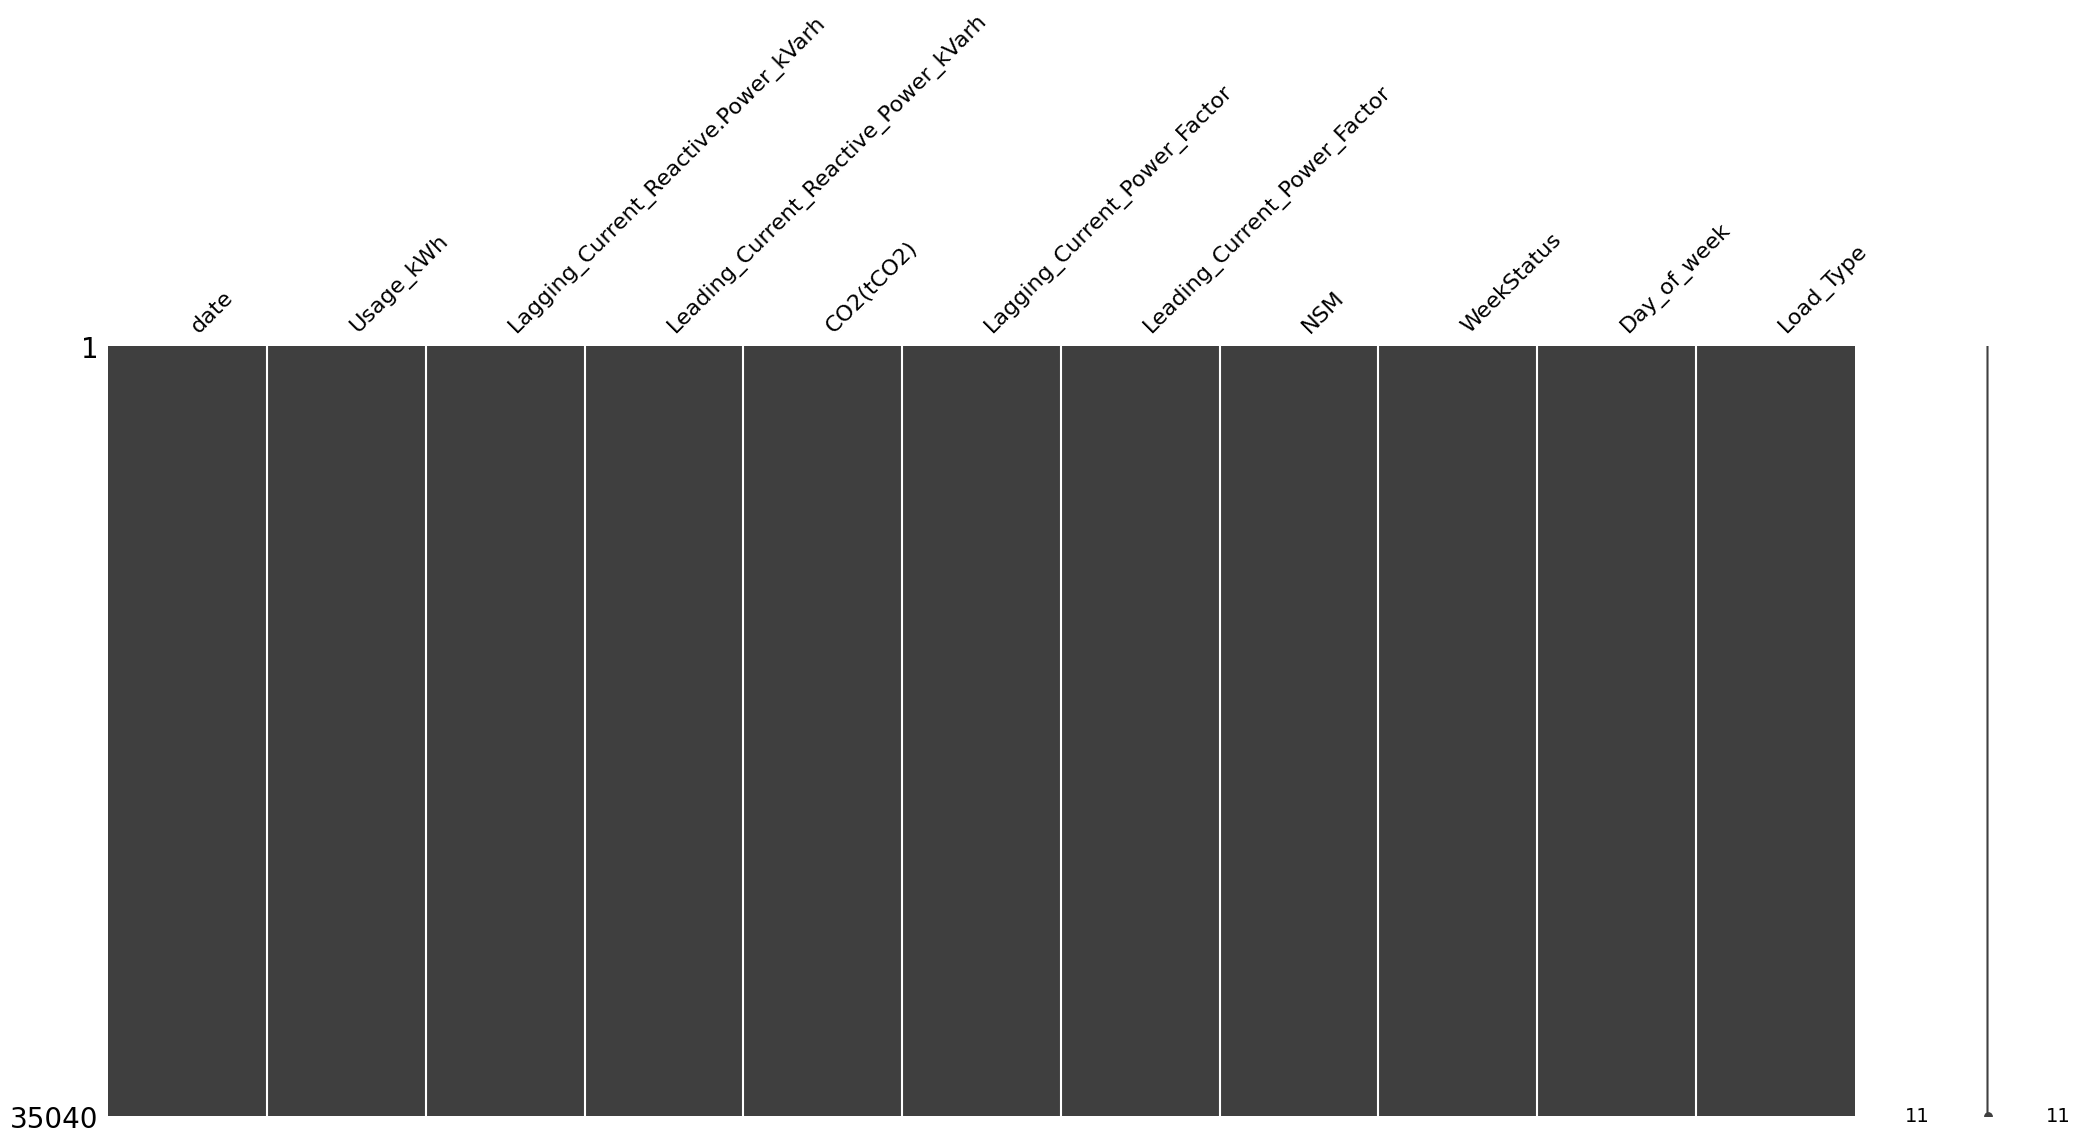

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

msno.matrix(df_steel)
df_steel.describe()
df_steel.isna().sum()


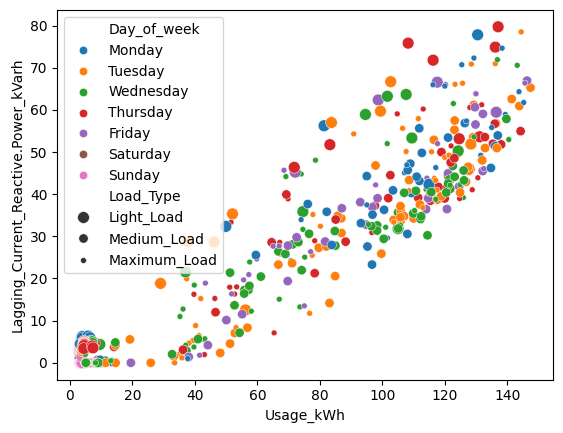

In [6]:
sns.scatterplot(data=df_small, x="Usage_kWh", y="Lagging_Current_Reactive.Power_kVarh", size="Load_Type", hue="Day_of_week")
plt.show()

In [7]:
df_steel2= pd.get_dummies(data=df_steel, columns=['WeekStatus'], prefix='WS_')
df_steel2= pd.get_dummies(data=df_steel2, columns=['Day_of_week'], prefix='Day_')
df_steel2= pd.get_dummies(data=df_steel2, columns=['Load_Type'], prefix='Load_')
df_steel2.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WS__Weekday,WS__Weekend,Day__Friday,Day__Monday,Day__Saturday,Day__Sunday,Day__Thursday,Day__Tuesday,Day__Wednesday,Load__Light_Load,Load__Maximum_Load,Load__Medium_Load
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,True,False,False,True,False,False,False,False,False,True,False,False
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,True,False,False,True,False,False,False,False,False,True,False,False
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,True,False,False,True,False,False,False,False,False,True,False,False
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,True,False,False,True,False,False,False,False,False,True,False,False
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,True,False,False,True,False,False,False,False,False,True,False,False


In [8]:
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import  train_test_split

num_features = [
    "Lagging_Current_Power_Factor",
    "Leading_Current_Power_Factor",
    "NSM"
]

cat_features = [
    "WeekStatus",
    "Day_of_week",
    "Load_Type"
]

scaler = StandardScaler()

preprocessing = ColumnTransformer(
    transformers=[
        ("num", scaler, num_features),
        ("cat", OneHotEncoder(drop='first'), cat_features)
        ]
)

X = df_steel2.drop(columns=[
    'Usage_kWh',
    "date",
    "Lagging_Current_Reactive.Power_kVarh",
    "Leading_Current_Reactive_Power_kVarh",
    "CO2(tCO2)"])
y = df_steel2['Usage_kWh']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])

In [9]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
score = model.score(X_test, y_test)

print(f"-- Accuracy: {score:.4f} -- ")

-- Accuracy: 0.6175 -- 


In [10]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
y_pred = model.predict(X_test)
MSE = mean_squared_error(y_test, y_pred)
MAE = mean_absolute_error(y_test, y_pred)
R2 = r2_score(y_test, y_pred)
print(f'MSE = {MSE} \nMAE = {MAE} \nR2 = {R2}')

MSE = 434.8338920585362 
MAE = 15.26172260790356 
R2 = 0.6174669243329696


In [11]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=50,
    criterion='squared_error'
)

model.fit(X_train, y_train)
score = model.score(X_test, y_test)

print(f"-- Accuracy: {score:.4f} -- ")

-- Accuracy: 0.8216 -- 


In [12]:
import xgboost as xgb

model = xgb.XGBRegressor(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        random_state=42)

model.fit(X_train, y_train)
score = model.score(X_test, y_test)

print(f"-- Accuracy: {score:.4f} -- ")

-- Accuracy: 0.8422 -- 


In [13]:
from lightgbm import LGBMRegressor

model = LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.005,
        num_leaves=31,
        boosting_type='gbdt',
        importance_type='gain'
    )

model.fit(X_train, y_train)
score = model.score(X_test, y_test)

print(f"-- Accuracy: {score:.4f} -- ")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004522 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 551
[LightGBM] [Info] Number of data points in the train set: 28032, number of used features: 15
[LightGBM] [Info] Start training from score 27.286074
-- Accuracy: 0.8451 -- 


In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Input, Dropout
from keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau, EarlyStopping, TensorBoard, ModelCheckpoint

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    # Dense(1024, activation='relu'),
    # Dropout(0.3),
    # Dense(512, activation='relu'),
    # Dropout(0.3),
    # Dense(256, activation='relu'),
    # Dropout(0.2),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='linear')
]
)

lr_reducer = ReduceLROnPlateau(
    monitor='val_loss',     # On surveille la perte sur les données de test
    factor=0.2,             # On divise le LR par 5 (LR * 0.2)
    patience=3,             # On attend 3 époques sans amélioration avant de réduire
    min_lr=1e-8,            # Limite basse pour ne pas descendre à zéro
    verbose=1               # Affiche un message à chaque réduction
)

early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=10
)

tensorboard_callback = TensorBoard(log_dir="logs/")

checkpoint_callback = ModelCheckpoint(
    filepath=f"model.keras",    # Chemin du fichier pour sauvegarder le modèle
    monitor="val_loss",         # Métrique à surveiller
    save_best_only=True,        # Sauvegarder uniquement le meilleur modèle
    mode="min"                  # Mode de comparaison (max pour l'accuracy)
)

optimizer = Adam(learning_rate=0.001)

model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])


In [ ]:
import mlflow
import mlflow.keras

mlflow.end_run()
mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("Steel_Industry_Usage")

mlflow.keras.autolog()

with mlflow.start_run(run_name="Run_Steel_indus"):
    history = model.fit(X_train, y_train, 
                        epochs=100, 
                        batch_size=128, 
                        validation_split=0.2,
                        verbose=1,
                        callbacks=[
                            lr_reducer,
                            early_stopping,
                            tensorboard_callback,
                            checkpoint_callback
                        ])

2026/02/23 15:54:40 WARNING mlflow.keras.autologging: Unrecognized dataset type <class 'pandas.core.frame.DataFrame'>. Dataset logging skipped.


Epoch 1/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - loss: 447.9379 - mae: 12.4580 - val_loss: 278.1743 - val_mae: 9.4094 - learning_rate: 0.0010
Epoch 2/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 292.4981 - mae: 9.6338 - val_loss: 281.8569 - val_mae: 9.2579 - learning_rate: 0.0010
Epoch 3/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 282.8065 - mae: 9.3677 - val_loss: 283.2045 - val_mae: 8.8011 - learning_rate: 0.0010
Epoch 4/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 269.0590 - mae: 9.1205 - val_loss: 238.9462 - val_mae: 8.8318 - learning_rate: 0.0010
Epoch 5/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 249.8666 - mae: 8.7928 - val_loss: 231.7054 - val_mae: 8.8423 - learning_rate: 0.0010
Epoch 6/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 243.1827 - mae: 8.5396 - val_loss: 229.2142 - val_mae: 8.1767 - learning_rate: 0.0010
Epoch 7/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 248.8208 - mae: 8.6102 - val_loss: 226.3378 - va

2026/02/23 15:57:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [ ]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_42 (Dense)                │ (None, 1024)           │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,613 (8.07 MB)

 Trainable params: 705,537 (2.69 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,411,076 (5.38 MB)

In [ ]:
y_pred = model.predict(X_test)
MSE = mean_squared_error(y_test, y_pred)
MAE = mean_absolute_error(y_test, y_pred)
R2 = r2_score(y_test, y_pred)
print(f'MSE = {MSE} \nMAE = {MAE} \nR2 = {R2}')

219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
MSE = 201.99408008382818 
MAE = 7.624834741510485 
R2 = 0.8223013014114423


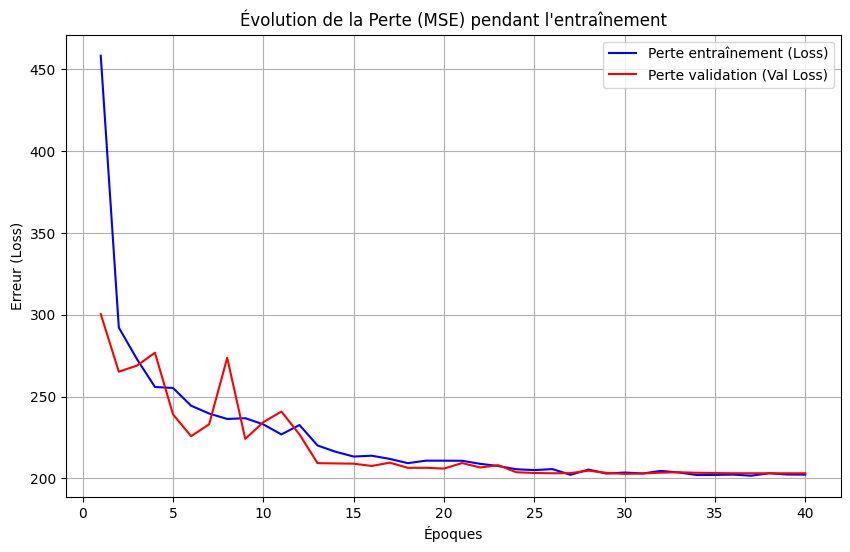

In [ ]:
import matplotlib.pyplot as plt

# Extraire les données de l'historique
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)

# Création du graphique
plt.figure(figsize=(10, 6))
plt.plot(epochs, loss, 'b-', label='Perte entraînement (Loss)')
plt.plot(epochs, val_loss, 'r-', label='Perte validation (Val Loss)')

plt.title('Évolution de la Perte (MSE) pendant l\'entraînement')
plt.xlabel('Époques')
plt.ylabel('Erreur (Loss)')
plt.legend()
plt.grid(True)
plt.show()